# **Notebook 6: Fine-Tuning Pipeline**
## Assignment: Hybrid RAG & Fine-Tuning for Customer Support
---

### TO-DO: Before Running This Notebook

**Files you NEED:**
- [ ] `./tokenized_train/` + `./tokenized_valid/` — Created by Notebook 2
- [ ] GPU runtime enabled (T4 minimum)

**Files this notebook will CREATE:**
- [ ] `./intent_lora_best/` — Best LoRA checkpoint (by val loss) _(Required by NB7)_
- [ ] `./intent_lora/` — Final LoRA checkpoint _(Backup)_
- [ ] `training_log.csv` + `training_curves.png` — Evidence for report

---

In [2]:
# ============================================================
# COLAB PROJECT SETUP
# ============================================================

from google.colab import drive
from pathlib import Path
import os

# Mount Google Drive
drive.mount("/content/drive")

# Permanent project folder in Google Drive
DRIVE_PROJECT_DIR = Path(
    "/content/drive/MyDrive/Hybrid_RAG_Customer_Support"
)

# Temporary workspace for the current Colab runtime
LOCAL_PROJECT_DIR = Path(
    "/content/Hybrid_RAG_Customer_Support"
)

LOCAL_PROJECT_DIR.mkdir(parents=True, exist_ok=True)

# Work from the temporary Colab directory
os.chdir(LOCAL_PROJECT_DIR)

print("Google Drive project:", DRIVE_PROJECT_DIR)
print("Local Colab workspace:", LOCAL_PROJECT_DIR)
print("Current working directory:", Path.cwd())

Mounted at /content/drive
Google Drive project: /content/drive/MyDrive/Hybrid_RAG_Customer_Support
Local Colab workspace: /content/Hybrid_RAG_Customer_Support
Current working directory: /content/Hybrid_RAG_Customer_Support


In [3]:
# ============================================================
# VERIFY GPU RUNTIME
# ============================================================

import torch

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU runtime is not enabled. In Colab, go to "
        "Runtime → Change runtime type → T4 GPU."
    )

gpu_name = torch.cuda.get_device_name(0)
gpu_memory_gb = (
    torch.cuda.get_device_properties(0).total_memory
    / 1024**3
)

print("GPU detected    :", gpu_name)
print(f"GPU memory      : {gpu_memory_gb:.2f} GB")
print("CUDA version    :", torch.version.cuda)
print("\nGPU runtime is enabled successfully.")

PyTorch version : 2.11.0+cu128
CUDA available  : True
GPU detected    : Tesla T4
GPU memory      : 14.56 GB
CUDA version    : 12.8

GPU runtime is enabled successfully.


## **Stage 4: Solution V2 (Fine-Tuned Retrieval-Assisted Generation)**

### **Task 4.1: Configure Fine-Tuning Pipeline**

#### **4.1.1 Configure PEFT Framework [3 marks]**
**The Task:** Apply LoRA (or QLoRA) to the model's `q_proj` and `v_proj` attention modules, set adapter settings and target modules, and prepare the training environment.

**Hints & Tips:**
* LoRA adds small trainable matrices to frozen attention layers — only ~0.5–1% of params update.
* `r=16` = rank of the low-rank matrices; `lora_alpha=32` scales them (rule of thumb: alpha = 2×r).
* `target_modules=["q_proj","v_proj"]`. Adding `["k_proj","o_proj"]` trains more params but may overfit on small data.
* Call `peft_model.print_trainable_parameters()` to confirm the tiny trainable %.

**LoRA Config Tuning:**
* `r`: 8 (lighter), **16 (recommended)**, 32 (more capacity).
* `lora_alpha`: usually 2×r → 16, **32**, 64.

**Learner Inference:** Updating only attention projections fundamentally changes behaviour (chat → JSON) using a fraction of the compute.

In [4]:
# YOUR CODE HERE
%pip install -q \
    "transformers==4.53.2" \
    "tokenizers==0.21.4" \
    "peft==0.16.0" \
    "bitsandbytes==0.46.1" \
    "accelerate==1.8.1"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 124.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 116.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.3/472.3 kB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.3/365.3 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [5]:
import random
from pathlib import Path

import numpy as np
import torch

from datasets import load_from_disk
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig
)
from peft import (
    LoraConfig,
    TaskType,
    get_peft_model,
    prepare_model_for_kbit_training
)

# Reproducibility and model configuration
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

if not torch.cuda.is_available():
    raise RuntimeError(
        "A T4 or better GPU runtime is required for QLoRA training."
    )

print("GPU:", torch.cuda.get_device_name(0))

# Load Notebook 2 training and validation artefacts
TOKENIZED_TRAIN_PATH = (
    DRIVE_PROJECT_DIR
    / "artifacts"
    / "notebook_2"
    / "tokenized_train"
)

TOKENIZED_VALID_PATH = (
    DRIVE_PROJECT_DIR
    / "artifacts"
    / "notebook_2"
    / "tokenized_valid"
)

for dataset_path in [
    TOKENIZED_TRAIN_PATH,
    TOKENIZED_VALID_PATH
]:
    if not dataset_path.exists():
        raise FileNotFoundError(
            f"Required tokenised dataset was not found:\n"
            f"{dataset_path}"
        )

tokenized_train = load_from_disk(
    str(TOKENIZED_TRAIN_PATH)
)

tokenized_valid = load_from_disk(
    str(TOKENIZED_VALID_PATH)
)

required_model_columns = {
    "input_ids",
    "attention_mask",
    "labels"
}

for dataset_name, dataset in [
    ("training", tokenized_train),
    ("validation", tokenized_valid)
]:
    missing_columns = (
        required_model_columns
        - set(dataset.column_names)
    )

    if missing_columns:
        raise ValueError(
            f"The {dataset_name} dataset is missing columns: "
            f"{sorted(missing_columns)}"
        )

print("\nTokenised datasets loaded")
print("-" * 55)
print(f"Training records   : {len(tokenized_train):,}")
print(f"Validation records : {len(tokenized_valid):,}")
print(f"Dataset columns    : {tokenized_train.column_names}")

GPU: Tesla T4

Tokenised datasets loaded
-------------------------------------------------------
Training records   : 3,200
Validation records : 400
Dataset columns    : ['instruction', 'intent', 'category', 'chatml_text', 'input_ids', 'attention_mask', 'labels']


In [6]:
# Configure 4-bit NF4 quantisation
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

# Load tokenizer and quantised base model
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    use_fast=True
)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=quantization_config,
    device_map="auto",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True
)

# Required during training with gradient checkpointing
base_model.config.use_cache = False

print("\nQuantised base model loaded")
print("-" * 55)
print(f"Model ID          : {MODEL_ID}")
print(f"Loaded in 4-bit   : {base_model.is_loaded_in_4bit}")
print(f"Padding token     : {tokenizer.pad_token}")
print(f"Padding token ID  : {tokenizer.pad_token_id}")
print(
    f"Model footprint   : "
    f"{base_model.get_memory_footprint() / 1024**3:.2f} GB"
)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:212: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]


Quantised base model loaded
-------------------------------------------------------
Model ID          : Qwen/Qwen2.5-1.5B-Instruct
Loaded in 4-bit   : True
Padding token     : <|endoftext|>
Padding token ID  : 151643
Model footprint   : 1.05 GB


In [7]:
# Prepare the model for k-bit training
base_model = prepare_model_for_kbit_training(
    base_model,
    use_gradient_checkpointing=True
)

base_model.gradient_checkpointing_enable()

# Confirm the requested target modules exist
TARGET_MODULES = [
    "q_proj",
    "v_proj"
]

available_module_names = {
    module_name.split(".")[-1]
    for module_name, _ in base_model.named_modules()
}

missing_target_modules = (
    set(TARGET_MODULES)
    - available_module_names
)

if missing_target_modules:
    raise ValueError(
        "The following LoRA target modules were not found in "
        f"the model: {sorted(missing_target_modules)}"
    )

# Configure and apply LoRA adapters
LORA_RANK = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=TARGET_MODULES,
    bias="none",
    inference_mode=False
)

peft_model = get_peft_model(
    base_model,
    lora_config
)

# Validate trainable parameters
trainable_parameters = sum(
    parameter.numel()
    for parameter in peft_model.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in peft_model.parameters()
)

trainable_percentage = (
    trainable_parameters
    / total_parameters
    * 100
)

assert trainable_parameters > 0
assert trainable_parameters < total_parameters

print("\nQLoRA configuration")
print("-" * 55)
print(f"LoRA rank          : {LORA_RANK}")
print(f"LoRA alpha         : {LORA_ALPHA}")
print(f"LoRA dropout       : {LORA_DROPOUT}")
print(f"Target modules     : {TARGET_MODULES}")
print(f"Task type          : {lora_config.task_type}")
print(f"Trainable params   : {trainable_parameters:,}")
print(f"Total params       : {total_parameters:,}")
print(f"Trainable percent  : {trainable_percentage:.4f}%")

print("\nPEFT parameter summary:")
peft_model.print_trainable_parameters()

# Final environment validation
assert peft_model.peft_config
assert peft_model.config.use_cache is False
assert peft_model.is_gradient_checkpointing

print("\nQLoRA training environment configured successfully.")


QLoRA configuration
-------------------------------------------------------
LoRA rank          : 16
LoRA alpha         : 32
LoRA dropout       : 0.05
Target modules     : ['q_proj', 'v_proj']
Task type          : TaskType.CAUSAL_LM
Trainable params   : 2,179,072
Total params       : 890,795,520
Trainable percent  : 0.2446%

PEFT parameter summary:
trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410

QLoRA training environment configured successfully.


#### **4.1.2 Configure Training Parameters [2 marks]**
**The Task:** Define the learning rate, batch size, number of steps/epochs, optimisation strategy (AdamW), and quantisation settings.

**Hints & Tips:**
* Initialise `AdamW(filter(lambda p: p.requires_grad, peft_model.parameters()), lr=2e-4)`.
* Build `DataLoader`s for the train and validation sets (remember `set_format("torch", ...)` after `load_from_disk`).
* Define `VAL_EVERY` (e.g. 10 steps) and an early-stopping `PATIENCE` (e.g. 3) for the next task.

**Parameter Tuning:**
* `lr=2e-4` standard; try `1e-4` (slower) or `5e-4` (faster).
* `batch_size=4` fits T4; use 2 if OOM, 8 on A100.
* `max_steps=200`: ~25% of one epoch on 3200 rows. Increase to 400–500 for a full epoch.

**Learner Inference:** These hyperparameters control how fast and how stably the adapter learns the JSON-extraction task.

In [8]:
# YOUR CODE HERE
import math
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup

# Training hyperparameters
LEARNING_RATE = 2e-4

TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4

# Effective training batch size:
# 4 examples × 4 accumulation steps = 16
GRADIENT_ACCUMULATION_STEPS = 4

NUM_EPOCHS = 3

WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0

WARMUP_RATIO = 0.05

# Run validation every 25 optimiser updates
VAL_EVERY = 25

# Stop after 3 consecutive validation checks without improvement
PATIENCE = 3
MIN_DELTA = 1e-4

USE_MIXED_PRECISION = True

MODEL_COLUMNS = [
    "input_ids",
    "attention_mask",
    "labels"
]

# Apply assistant-only label masking

# The Notebook 2 artefacts currently mask padding tokens.
# For intent-router fine-tuning, system and user tokens should
# also be ignored so loss is calculated only on assistant JSON.

ASSISTANT_PREFIX_IDS = tokenizer.encode(
    "<|im_start|>assistant\n",
    add_special_tokens=False
)


def find_subsequence(sequence, subsequence):
    """Return the first index of a token subsequence."""

    subsequence_length = len(subsequence)

    for index in range(
        len(sequence) - subsequence_length + 1
    ):
        if (
            sequence[
                index:index + subsequence_length
            ]
            == subsequence
        ):
            return index

    return -1


def apply_assistant_only_mask(example):
    """
    Set labels to -100 for system, user and padding tokens.
    Retain labels only for the assistant JSON response.
    """

    input_ids = list(example["input_ids"])
    attention_mask = list(example["attention_mask"])

    assistant_start = find_subsequence(
        input_ids,
        ASSISTANT_PREFIX_IDS
    )

    if assistant_start == -1:
        raise ValueError(
            "Assistant section was not found in a ChatML record."
        )

    target_start = (
        assistant_start
        + len(ASSISTANT_PREFIX_IDS)
    )

    labels = [-100] * len(input_ids)

    for token_index in range(
        target_start,
        len(input_ids)
    ):
        # Keep only non-padding assistant tokens
        if attention_mask[token_index] == 1:
            labels[token_index] = input_ids[token_index]

    if all(label == -100 for label in labels):
        raise ValueError(
            "No trainable assistant tokens remain after masking."
        )

    return {
        "labels": labels
    }


train_dataset = tokenized_train.map(
    apply_assistant_only_mask,
    desc="Applying assistant-only masking to training data"
)

valid_dataset = tokenized_valid.map(
    apply_assistant_only_mask,
    desc="Applying assistant-only masking to validation data"
)

In [9]:
train_dataset.reset_format()
valid_dataset.reset_format()

# Verify the required columns exist
for dataset_name, dataset in [
    ("train_dataset", train_dataset),
    ("valid_dataset", valid_dataset)
]:
    missing_columns = [
        column
        for column in MODEL_COLUMNS
        if column not in dataset.column_names
    ]

    if missing_columns:
        raise ValueError(
            f"{dataset_name} is missing: {missing_columns}"
        )


def causal_lm_collate_fn(features):
    """Create a text-only causal-LM batch."""

    return {
        "input_ids": torch.tensor(
            [feature["input_ids"] for feature in features],
            dtype=torch.long
        ),
        "attention_mask": torch.tensor(
            [feature["attention_mask"] for feature in features],
            dtype=torch.long
        ),
        "labels": torch.tensor(
            [feature["labels"] for feature in features],
            dtype=torch.long
        )
    }


train_generator = torch.Generator()
train_generator.manual_seed(RANDOM_STATE)

# Recreate both loaders; do not reuse the older objects
train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    generator=train_generator,
    num_workers=0,
    pin_memory=True,
    collate_fn=causal_lm_collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=causal_lm_collate_fn
)


# Validate the newly rebuilt loader
sample_batch = next(iter(train_loader))

print("Sample batch keys:", list(sample_batch.keys()))
print("Expected keys    :", list(MODEL_COLUMNS))

assert set(MODEL_COLUMNS).issubset(sample_batch.keys())

assert (
    sample_batch["input_ids"].shape
    == sample_batch["attention_mask"].shape
    == sample_batch["labels"].shape
)

print("Batch shape:", sample_batch["input_ids"].shape)
print("Text-only DataLoaders rebuilt successfully.")

Sample batch keys: ['input_ids', 'attention_mask', 'labels']
Expected keys    : ['input_ids', 'attention_mask', 'labels']
Batch shape: torch.Size([4, 128])
Text-only DataLoaders rebuilt successfully.


In [10]:
# Calculate training-step configuration
optimizer_steps_per_epoch = math.ceil(
    len(train_loader)
    / GRADIENT_ACCUMULATION_STEPS
)

TOTAL_OPTIMIZER_STEPS = (
    optimizer_steps_per_epoch
    * NUM_EPOCHS
)

WARMUP_STEPS = max(
    1,
    int(
        TOTAL_OPTIMIZER_STEPS
        * WARMUP_RATIO
    )
)

# Configure AdamW optimiser
trainable_parameters = [
    parameter
    for parameter in peft_model.parameters()
    if parameter.requires_grad
]

optimizer = AdamW(
    trainable_parameters,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Configure linear learning-rate scheduler
lr_scheduler = get_linear_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=TOTAL_OPTIMIZER_STEPS
)

In [11]:
# Validate DataLoader and label masking
sample_batch = next(iter(train_loader))

assert set(sample_batch.keys()) == set(
    MODEL_COLUMNS
)

assert (
    sample_batch["input_ids"].shape
    == sample_batch["attention_mask"].shape
    == sample_batch["labels"].shape
)

assistant_token_count = int(
    (
        sample_batch["labels"] != -100
    ).sum()
)

ignored_token_count = int(
    (
        sample_batch["labels"] == -100
    ).sum()
)

assert assistant_token_count > 0

# Decode one target to verify that only the assistant response
# contributes to the training loss.
sample_target_ids = [
    label.item()
    for label in sample_batch["labels"][0]
    if label.item() != -100
]

decoded_training_target = tokenizer.decode(
    sample_target_ids,
    skip_special_tokens=False
)

# Display complete training configuration
print("Training parameters configured successfully")
print("=" * 60)

print(f"Learning rate                 : {LEARNING_RATE}")
print(f"Optimiser                     : AdamW")
print(f"Weight decay                  : {WEIGHT_DECAY}")
print(f"Training batch size           : {TRAIN_BATCH_SIZE}")
print(f"Validation batch size         : {EVAL_BATCH_SIZE}")
print(
    f"Gradient accumulation steps   : "
    f"{GRADIENT_ACCUMULATION_STEPS}"
)
print(
    f"Effective training batch size : "
    f"{TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS}"
)
print(f"Maximum epochs                : {NUM_EPOCHS}")
print(
    f"Optimiser steps per epoch     : "
    f"{optimizer_steps_per_epoch}"
)
print(
    f"Maximum optimiser steps       : "
    f"{TOTAL_OPTIMIZER_STEPS}"
)
print(f"Warmup steps                  : {WARMUP_STEPS}")
print(f"Validation interval           : {VAL_EVERY} steps")
print(f"Early-stopping patience       : {PATIENCE}")
print(f"Minimum validation improvement: {MIN_DELTA}")
print(f"Maximum gradient norm         : {MAX_GRAD_NORM}")
print(f"Mixed precision enabled       : {USE_MIXED_PRECISION}")

print("\nDataLoader configuration")
print("-" * 60)
print(f"Training batches   : {len(train_loader)}")
print(f"Validation batches : {len(valid_loader)}")
print(f"Batch tensor shape : {sample_batch['input_ids'].shape}")

print("\nLabel-masking validation")
print("-" * 60)
print(f"Assistant target tokens : {assistant_token_count}")
print(f"Ignored token positions : {ignored_token_count}")
print("\nDecoded assistant-only training target:")
print(decoded_training_target)

Training parameters configured successfully
Learning rate                 : 0.0002
Optimiser                     : AdamW
Weight decay                  : 0.01
Training batch size           : 4
Validation batch size         : 4
Gradient accumulation steps   : 4
Effective training batch size : 16
Maximum epochs                : 3
Optimiser steps per epoch     : 200
Maximum optimiser steps       : 600
Warmup steps                  : 30
Validation interval           : 25 steps
Early-stopping patience       : 3
Minimum validation improvement: 0.0001
Maximum gradient norm         : 1.0
Mixed precision enabled       : True

DataLoader configuration
------------------------------------------------------------
Training batches   : 800
Validation batches : 100
Batch tensor shape : torch.Size([4, 128])

Label-masking validation
------------------------------------------------------------
Assistant target tokens : 53
Ignored token positions : 459

Decoded assistant-only training target:
{"intent":"

### **Task 4.2: Train Fine-Tuned Model**

#### **4.2.1 Execute Fine-Tuning [5 marks]**
**The Task:** Run the custom PyTorch training loop. Monitor BOTH train and validation loss at regular intervals, implement early stopping based on validation loss, and plot the train-vs-validation loss curves.

**Hints & Tips:**
* The validation loop runs every `VAL_EVERY` steps under `torch.no_grad()` (no gradients).
* Early stopping: track `best_val_loss`; if it doesn't improve for `PATIENCE` checks, stop.
* The loss-curve plot is mandatory evidence — save it as `training_curves.png`.

**What to look for in the curve:**
* Both lines falling → learning, no overfitting.
* Val rises while train falls → overfitting (early stopping saves you).
* Both flat → LR too low or data too small.
* Val spikes → bad batch / instability.

**Learner Inference:** Falling loss proves gradient descent is teaching the JSON format. Validation monitoring prevents silent memorisation.

In [12]:
# YOUR CODE HERE
import json
import math
import shutil
import time
from pathlib import Path

import pandas as pd
import numpy as np
from IPython.display import display

from tqdm.auto import tqdm

# Define Notebook 6 output paths
NOTEBOOK_6_ARTIFACT_DIR = (
    DRIVE_PROJECT_DIR
    / "artifacts"
    / "notebook_6"
)

BEST_ADAPTER_PATH = (
    NOTEBOOK_6_ARTIFACT_DIR
    / "intent_lora_best"
)

TRAINING_CURVE_PATH = (
    NOTEBOOK_6_ARTIFACT_DIR
    / "training_curves.png"
)

NOTEBOOK_6_ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Remove an older best checkpoint before a fresh training run
if BEST_ADAPTER_PATH.exists():
    shutil.rmtree(BEST_ADAPTER_PATH)

TRAIN_DEVICE = torch.device("cuda:0")

# Configure automatic mixed precision
# Supports current and slightly older PyTorch AMP interfaces
try:
    gradient_scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_MIXED_PRECISION
    )
except TypeError:
    gradient_scaler = torch.cuda.amp.GradScaler(
        enabled=USE_MIXED_PRECISION
    )


def move_batch_to_device(batch):
    """Move a text-only causal-LM batch to the GPU."""

    return {
        key: value.to(
            TRAIN_DEVICE,
            non_blocking=True
        )
        for key, value in batch.items()
    }

# Validation-loss function
@torch.no_grad()
def calculate_validation_loss():
    """
    Calculate token-weighted validation loss without gradients.
    """

    peft_model.eval()

    weighted_loss_sum = 0.0
    target_token_count = 0

    for validation_batch in valid_loader:

        validation_batch = move_batch_to_device(
            validation_batch
        )

        valid_target_tokens = int(
            (
                validation_batch["labels"] != -100
            ).sum().item()
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_MIXED_PRECISION
        ):
            validation_outputs = peft_model(
                **validation_batch
            )

            validation_loss = (
                validation_outputs.loss
            )

        if not torch.isfinite(validation_loss):
            raise RuntimeError(
                "Non-finite validation loss was detected."
            )

        weighted_loss_sum += (
            validation_loss.item()
            * valid_target_tokens
        )

        target_token_count += valid_target_tokens

    if target_token_count == 0:
        raise RuntimeError(
            "The validation set contains no trainable target tokens."
        )

    average_validation_loss = (
        weighted_loss_sum
        / target_token_count
    )

    peft_model.train()

    return average_validation_loss

In [13]:
# Initialise training state
best_validation_loss = float("inf")
best_global_step = None

patience_counter = 0
global_step = 0

early_stopping_triggered = False
training_history = []

optimizer.zero_grad(
    set_to_none=True
)

peft_model.train()

training_start_time = time.perf_counter()

# Run the custom training loop
for epoch_index in range(NUM_EPOCHS):

    if early_stopping_triggered:
        break

    epoch_number = epoch_index + 1

    print(
        f"\nEpoch {epoch_number}/{NUM_EPOCHS}"
    )
    print("-" * 65)

    interval_weighted_loss = 0.0
    interval_target_tokens = 0

    progress_bar = tqdm(
        enumerate(train_loader, start=1),
        total=len(train_loader),
        desc=f"Epoch {epoch_number}"
    )

    for micro_batch_step, training_batch in progress_bar:

        training_batch = move_batch_to_device(
            training_batch
        )

        batch_target_tokens = int(
            (
                training_batch["labels"] != -100
            ).sum().item()
        )

        if batch_target_tokens == 0:
            raise RuntimeError(
                "A training batch contains no target tokens."
            )

        # Forward pass under mixed precision
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_MIXED_PRECISION
        ):
            training_outputs = peft_model(
                **training_batch
            )

            raw_training_loss = (
                training_outputs.loss
            )

            # Scale for gradient accumulation
            backward_loss = (
                raw_training_loss
                / GRADIENT_ACCUMULATION_STEPS
            )

        if not torch.isfinite(raw_training_loss):
            raise RuntimeError(
                "Non-finite training loss was detected."
            )

        # Backward pass
        gradient_scaler.scale(
            backward_loss
        ).backward()

        interval_weighted_loss += (
            raw_training_loss.item()
            * batch_target_tokens
        )

        interval_target_tokens += (
            batch_target_tokens
        )

        is_accumulation_boundary = (
            micro_batch_step
            % GRADIENT_ACCUMULATION_STEPS
            == 0
        )

        is_final_micro_batch = (
            micro_batch_step
            == len(train_loader)
        )

        if not (
            is_accumulation_boundary
            or is_final_micro_batch
        ):
            continue

        # Optimiser update
        gradient_scaler.unscale_(
            optimizer
        )

        gradient_norm = (
            torch.nn.utils.clip_grad_norm_(
                peft_model.parameters(),
                MAX_GRAD_NORM
            )
        )

        previous_scale = (
            gradient_scaler.get_scale()
        )

        gradient_scaler.step(
            optimizer
        )

        gradient_scaler.update()

        current_scale = (
            gradient_scaler.get_scale()
        )

        # A lower scale indicates that the optimiser update was
        # skipped because invalid gradients were detected.
        optimiser_step_completed = (
            current_scale >= previous_scale
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        if not optimiser_step_completed:
            progress_bar.set_postfix(
                status="AMP step skipped"
            )
            continue

        lr_scheduler.step()
        global_step += 1

        progress_bar.set_postfix({
            "loss": (
                f"{raw_training_loss.item():.4f}"
            ),
            "step": global_step,
            "lr": (
                f"{optimizer.param_groups[0]['lr']:.2e}"
            )
        })

        # Periodic validation
        should_validate = (
            global_step % VAL_EVERY == 0
            or global_step
            == TOTAL_OPTIMIZER_STEPS
        )

        if not should_validate:
            continue

        average_training_loss = (
            interval_weighted_loss
            / interval_target_tokens
        )

        average_validation_loss = (
            calculate_validation_loss()
        )

        current_learning_rate = (
            optimizer.param_groups[0]["lr"]
        )

        validation_improved = (
            average_validation_loss
            < best_validation_loss - MIN_DELTA
        )

        if validation_improved:

            best_validation_loss = (
                average_validation_loss
            )

            best_global_step = global_step
            patience_counter = 0

            # Save the current best LoRA adapter
            peft_model.save_pretrained(
                str(BEST_ADAPTER_PATH),
                safe_serialization=True
            )

            tokenizer.save_pretrained(
                str(BEST_ADAPTER_PATH)
            )

            best_checkpoint_metadata = {
                "model_id": MODEL_ID,
                "best_global_step": int(
                    best_global_step
                ),
                "best_validation_loss": float(
                    best_validation_loss
                ),
                "epoch": int(epoch_number),
                "learning_rate": float(
                    current_learning_rate
                ),
                "lora_rank": int(LORA_RANK),
                "lora_alpha": int(LORA_ALPHA),
                "lora_dropout": float(
                    LORA_DROPOUT
                ),
                "target_modules": TARGET_MODULES,
                "train_batch_size": (
                    TRAIN_BATCH_SIZE
                ),
                "gradient_accumulation_steps": (
                    GRADIENT_ACCUMULATION_STEPS
                ),
                "effective_batch_size": (
                    TRAIN_BATCH_SIZE
                    * GRADIENT_ACCUMULATION_STEPS
                )
            }

            with open(
                BEST_ADAPTER_PATH
                / "best_checkpoint_metadata.json",
                "w",
                encoding="utf-8"
            ) as metadata_file:
                json.dump(
                    best_checkpoint_metadata,
                    metadata_file,
                    indent=2
                )

        else:
            patience_counter += 1

        training_history.append({
            "epoch": epoch_number,
            "global_step": global_step,
            "train_loss": (
                average_training_loss
            ),
            "validation_loss": (
                average_validation_loss
            ),
            "learning_rate": (
                current_learning_rate
            ),
            "gradient_norm": float(
                gradient_norm
            ),
            "validation_improved": (
                validation_improved
            ),
            "patience_counter": (
                patience_counter
            )
        })

        print(
            f"\nStep {global_step:>4} | "
            f"Train loss: "
            f"{average_training_loss:.5f} | "
            f"Validation loss: "
            f"{average_validation_loss:.5f} | "
            f"Best: {best_validation_loss:.5f} | "
            f"Patience: "
            f"{patience_counter}/{PATIENCE}"
        )

        # Reset interval-loss tracking
        interval_weighted_loss = 0.0
        interval_target_tokens = 0

        # Early stopping
        if patience_counter >= PATIENCE:

            early_stopping_triggered = True

            print(
                "\nEarly stopping triggered because "
                f"validation loss did not improve for "
                f"{PATIENCE} consecutive checks."
            )

            break

# Final training validation
training_duration_seconds = (
    time.perf_counter()
    - training_start_time
)

training_log_df = pd.DataFrame(
    training_history
)

if training_log_df.empty:
    raise RuntimeError(
        "No validation measurements were recorded."
    )

if not BEST_ADAPTER_PATH.exists():
    raise RuntimeError(
        "The best LoRA checkpoint was not saved."
    )

assert best_global_step is not None
assert np.isfinite(best_validation_loss)

print("\nFine-tuning completed")
print("=" * 65)
print(f"Completed optimiser steps : {global_step}")
print(f"Maximum planned steps     : {TOTAL_OPTIMIZER_STEPS}")
print(f"Best validation loss      : {best_validation_loss:.6f}")
print(f"Best checkpoint step      : {best_global_step}")
print(
    f"Early stopping triggered  : "
    f"{early_stopping_triggered}"
)
print(
    f"Training duration         : "
    f"{training_duration_seconds / 60:.2f} minutes"
)
print(f"Best adapter saved to:\n{BEST_ADAPTER_PATH}")

print("\nTraining history:")
display(training_log_df)


Epoch 1/3
-----------------------------------------------------------------


Epoch 1:   0%|          | 0/800 [00:00<?, ?it/s]


Step   25 | Train loss: 1.61240 | Validation loss: 0.73632 | Best: 0.73632 | Patience: 0/3

Step   50 | Train loss: 0.41477 | Validation loss: 0.19473 | Best: 0.19473 | Patience: 0/3

Step   75 | Train loss: 0.11121 | Validation loss: 0.05316 | Best: 0.05316 | Patience: 0/3

Step  100 | Train loss: 0.03917 | Validation loss: 0.02427 | Best: 0.02427 | Patience: 0/3

Step  125 | Train loss: 0.02428 | Validation loss: 0.01528 | Best: 0.01528 | Patience: 0/3

Step  150 | Train loss: 0.01234 | Validation loss: 0.01050 | Best: 0.01050 | Patience: 0/3

Step  175 | Train loss: 0.00962 | Validation loss: 0.01268 | Best: 0.01050 | Patience: 1/3

Step  200 | Train loss: 0.00558 | Validation loss: 0.00566 | Best: 0.00566 | Patience: 0/3

Epoch 2/3
-----------------------------------------------------------------


Epoch 2:   0%|          | 0/800 [00:00<?, ?it/s]


Step  225 | Train loss: 0.00469 | Validation loss: 0.00687 | Best: 0.00566 | Patience: 1/3

Step  250 | Train loss: 0.00425 | Validation loss: 0.00515 | Best: 0.00515 | Patience: 0/3

Step  275 | Train loss: 0.00365 | Validation loss: 0.00773 | Best: 0.00515 | Patience: 1/3

Step  300 | Train loss: 0.00385 | Validation loss: 0.00473 | Best: 0.00473 | Patience: 0/3

Step  325 | Train loss: 0.00260 | Validation loss: 0.00456 | Best: 0.00456 | Patience: 0/3

Step  350 | Train loss: 0.00277 | Validation loss: 0.00553 | Best: 0.00456 | Patience: 1/3

Step  375 | Train loss: 0.00198 | Validation loss: 0.00374 | Best: 0.00374 | Patience: 0/3

Step  400 | Train loss: 0.00131 | Validation loss: 0.00554 | Best: 0.00374 | Patience: 1/3

Epoch 3/3
-----------------------------------------------------------------


Epoch 3:   0%|          | 0/800 [00:00<?, ?it/s]


Step  425 | Train loss: 0.00104 | Validation loss: 0.00444 | Best: 0.00374 | Patience: 2/3

Step  450 | Train loss: 0.00101 | Validation loss: 0.00321 | Best: 0.00321 | Patience: 0/3

Step  475 | Train loss: 0.00062 | Validation loss: 0.00302 | Best: 0.00302 | Patience: 0/3

Step  500 | Train loss: 0.00060 | Validation loss: 0.00316 | Best: 0.00302 | Patience: 1/3

Step  525 | Train loss: 0.00047 | Validation loss: 0.00319 | Best: 0.00302 | Patience: 2/3

Step  550 | Train loss: 0.00055 | Validation loss: 0.00331 | Best: 0.00302 | Patience: 3/3

Early stopping triggered because validation loss did not improve for 3 consecutive checks.

Fine-tuning completed
Completed optimiser steps : 550
Maximum planned steps     : 600
Best validation loss      : 0.003020
Best checkpoint step      : 475
Early stopping triggered  : True
Training duration         : 32.66 minutes
Best adapter saved to:
/content/drive/MyDrive/Hybrid_RAG_Customer_Support/artifacts/notebook_6/intent_lora_best

Training his

,epoch,global_step,train_loss,validation_loss,learning_rate,gradient_norm,validation_improved,patience_counter
0,1,25,1.612395,0.736323,0.000167,1.373574,True,0
1,1,50,0.414767,0.194735,0.000193,1.197493,True,0
2,1,75,0.111213,0.053159,0.000184,1.077137,True,0
3,1,100,0.039170,0.024273,0.000175,2.145649,True,0
4,1,125,0.024276,0.015281,0.000167,0.916372,True,0
5,1,150,0.012343,0.010495,0.000158,0.391850,True,0
6,1,175,0.009625,0.012675,0.000149,0.730876,False,1
7,1,200,0.005576,0.005660,0.000140,0.036604,True,0
8,2,225,0.004691,0.006866,0.000132,0.080546,False,1
9,2,250,0.004248,0.005148,0.000123,0.404434,True,0


### Checkpoint Selection Note

Early stopping used `MIN_DELTA = 1e-4` so that only meaningful reductions in validation loss were treated as improvements. The lowest qualifying validation loss was **0.003020 at optimiser step 475**, so this checkpoint was retained as the best-performing adapter.

After step 475, validation loss increased to **0.003160**, **0.003190**, and **0.003310** at steps 500, 525, and 550, respectively. Since no qualifying improvement occurred for three consecutive validation checks, early stopping was triggered at step 550. This prevented unnecessary training beyond the point of best validation performance.

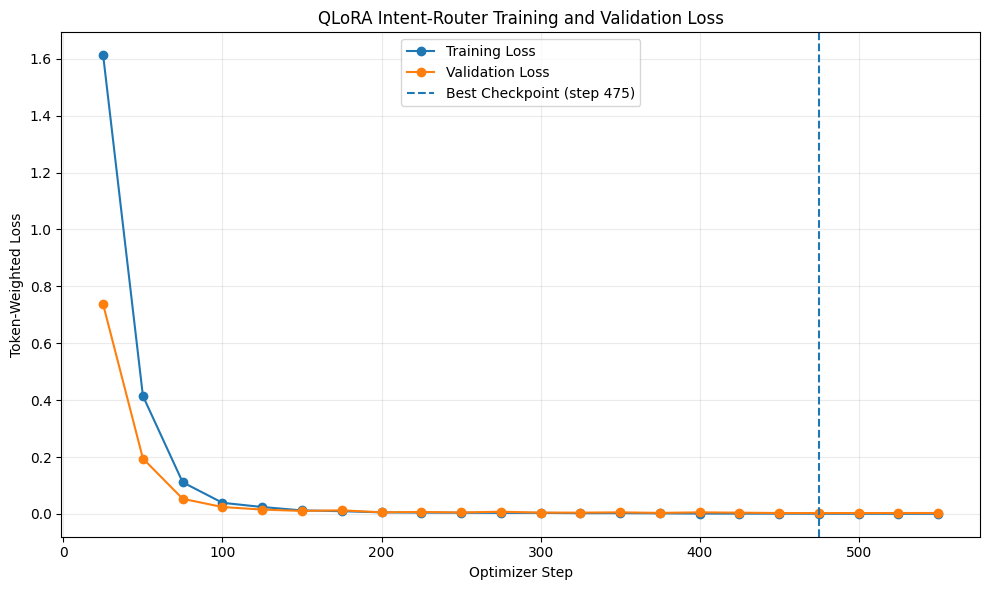

Training curve saved successfully
Curve path:
/content/drive/MyDrive/Hybrid_RAG_Customer_Support/artifacts/notebook_6/training_curves.png

Initial validation loss: 0.736323
Best validation loss   : 0.003020
Final validation loss  : 0.003310


In [14]:
# YOUR CODE HERE
import matplotlib.pyplot as plt


if training_log_df.empty:
    raise RuntimeError(
        "Training history is empty. Run fine-tuning first."
    )


plt.figure(figsize=(10, 6))

plt.plot(
    training_log_df["global_step"],
    training_log_df["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    training_log_df["global_step"],
    training_log_df["validation_loss"],
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    best_global_step,
    linestyle="--",
    label=(
        f"Best Checkpoint "
        f"(step {best_global_step})"
    )
)

plt.title(
    "QLoRA Intent-Router Training and Validation Loss"
)

plt.xlabel("Optimizer Step")
plt.ylabel("Token-Weighted Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    TRAINING_CURVE_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print("Training curve saved successfully")
print(f"Curve path:\n{TRAINING_CURVE_PATH}")

print(
    f"\nInitial validation loss: "
    f"{training_log_df['validation_loss'].iloc[0]:.6f}"
)

print(
    f"Best validation loss   : "
    f"{best_validation_loss:.6f}"
)

print(
    f"Final validation loss  : "
    f"{training_log_df['validation_loss'].iloc[-1]:.6f}"
)

#### **4.2.2 Save Training Outputs [2 marks]**
**The Task:** Save the best checkpoint (by validation loss), document the checkpoint/model-saving workflow, and export reproducibility information.

**Hints & Tips:**
* Save two checkpoints: `./intent_lora_best/` (lowest val loss) and `./intent_lora/` (final step).
* Export a `training_log.csv` with columns `step, train_loss, val_loss`.
* Record reproducibility info: model ID, LoRA config, learning rate, batch size, seed.

**Learner Inference:** Saving the BEST checkpoint (not the last) ensures your final model is the one that generalised best, not one that started overfitting.

In [15]:
# YOUR CODE HERE
import json
import os
import platform
import shutil
from importlib.metadata import version, PackageNotFoundError

import pandas as pd

# Define output paths
FINAL_ADAPTER_PATH = (
    NOTEBOOK_6_ARTIFACT_DIR
    / "intent_lora"
)

TRAINING_LOG_PATH = (
    NOTEBOOK_6_ARTIFACT_DIR
    / "training_log.csv"
)

REPRODUCIBILITY_PATH = (
    NOTEBOOK_6_ARTIFACT_DIR
    / "reproducibility_info.json"
)

NOTEBOOK_6_ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Validate completed training outputs
if "training_log_df" not in globals():
    training_log_df = pd.DataFrame(
        training_history
    )

if training_log_df.empty:
    raise RuntimeError(
        "Training history is empty. Complete or recover the "
        "training run before saving outputs."
    )

if not BEST_ADAPTER_PATH.exists():
    raise FileNotFoundError(
        f"The best validation-loss checkpoint was not found:\n"
        f"{BEST_ADAPTER_PATH}"
    )

if not TRAINING_CURVE_PATH.exists():
    raise FileNotFoundError(
        f"The training-curve image was not found:\n"
        f"{TRAINING_CURVE_PATH}"
    )

if best_global_step is None:
    raise RuntimeError(
        "The best checkpoint step was not recorded."
    )

# Save the final-step LoRA adapter as a backup
# Preserve intent_lora_best; replace only the final backup folder
if FINAL_ADAPTER_PATH.exists():
    shutil.rmtree(
        FINAL_ADAPTER_PATH
    )

peft_model.save_pretrained(
    str(FINAL_ADAPTER_PATH),
    safe_serialization=True
)

tokenizer.save_pretrained(
    str(FINAL_ADAPTER_PATH)
)

# Export the training log
training_log_export = (
    training_log_df
    .rename(
        columns={
            "global_step": "step",
            "validation_loss": "val_loss"
        }
    )
    .copy()
)

# Put the rubric-required columns first
required_log_columns = [
    "step",
    "train_loss",
    "val_loss"
]

missing_log_columns = [
    column
    for column in required_log_columns
    if column not in training_log_export.columns
]

if missing_log_columns:
    raise ValueError(
        f"Training log is missing required columns: "
        f"{missing_log_columns}"
    )

remaining_columns = [
    column
    for column in training_log_export.columns
    if column not in required_log_columns
]

training_log_export = training_log_export[
    required_log_columns + remaining_columns
]

TEMP_LOG_PATH = TRAINING_LOG_PATH.with_suffix(
    ".tmp"
)

training_log_export.to_csv(
    TEMP_LOG_PATH,
    index=False
)

os.replace(
    TEMP_LOG_PATH,
    TRAINING_LOG_PATH
)

In [16]:
# Collect package versions
def get_package_version(package_name):
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "not installed"


package_versions = {
    package: get_package_version(package)
    for package in [
        "torch",
        "transformers",
        "tokenizers",
        "peft",
        "bitsandbytes",
        "accelerate",
        "datasets"
    ]
}

# Save reproducibility and checkpoint metadata
reproducibility_info = {
    "base_model_id": MODEL_ID,
    "random_seed": RANDOM_STATE,
    "hardware": {
        "gpu": torch.cuda.get_device_name(0),
        "cuda_version": torch.version.cuda,
        "python_version": platform.python_version()
    },
    "quantisation": {
        "method": "QLoRA",
        "load_in_4bit": True,
        "quantisation_type": "NF4",
        "double_quantisation": True,
        "compute_dtype": "float16"
    },
    "lora_configuration": {
        "rank": LORA_RANK,
        "alpha": LORA_ALPHA,
        "dropout": LORA_DROPOUT,
        "target_modules": TARGET_MODULES,
        "bias": "none",
        "task_type": "CAUSAL_LM"
    },
    "training_configuration": {
        "optimizer": "AdamW",
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "train_batch_size": TRAIN_BATCH_SIZE,
        "validation_batch_size": EVAL_BATCH_SIZE,
        "gradient_accumulation_steps": (
            GRADIENT_ACCUMULATION_STEPS
        ),
        "effective_batch_size": (
            TRAIN_BATCH_SIZE
            * GRADIENT_ACCUMULATION_STEPS
        ),
        "maximum_epochs": NUM_EPOCHS,
        "maximum_optimizer_steps": (
            TOTAL_OPTIMIZER_STEPS
        ),
        "completed_optimizer_steps": global_step,
        "warmup_steps": WARMUP_STEPS,
        "validation_interval_steps": VAL_EVERY,
        "early_stopping_patience": PATIENCE,
        "minimum_validation_improvement": MIN_DELTA,
        "maximum_gradient_norm": MAX_GRAD_NORM,
        "mixed_precision": USE_MIXED_PRECISION,
        "label_masking": (
            "Loss calculated only on assistant JSON tokens; "
            "system, user and padding tokens use -100."
        )
    },
    "training_result": {
        "best_checkpoint_step": best_global_step,
        "best_validation_loss": float(
            best_validation_loss
        ),
        "final_recorded_validation_loss": float(
            training_log_export["val_loss"].iloc[-1]
        ),
        "early_stopping_triggered": bool(
            early_stopping_triggered
        ),
        "training_duration_minutes": round(
            training_duration_seconds / 60,
            2
        )
    },
    "saved_artifacts": {
        "best_adapter": str(
            BEST_ADAPTER_PATH
        ),
        "final_adapter_backup": str(
            FINAL_ADAPTER_PATH
        ),
        "training_log": str(
            TRAINING_LOG_PATH
        ),
        "training_curve": str(
            TRAINING_CURVE_PATH
        )
    },
    "package_versions": package_versions
}

TEMP_REPRO_PATH = (
    REPRODUCIBILITY_PATH.with_suffix(".tmp")
)

with open(
    TEMP_REPRO_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        reproducibility_info,
        file,
        indent=2,
        ensure_ascii=False
    )

os.replace(
    TEMP_REPRO_PATH,
    REPRODUCIBILITY_PATH
)

# Reload and validate saved outputs
saved_training_log = pd.read_csv(
    TRAINING_LOG_PATH
)

with open(
    REPRODUCIBILITY_PATH,
    "r",
    encoding="utf-8"
) as file:
    saved_reproducibility_info = json.load(file)

assert len(saved_training_log) == len(
    training_log_export
)

assert required_log_columns == (
    saved_training_log.columns[:3].tolist()
)

for required_file in [
    BEST_ADAPTER_PATH / "adapter_config.json",
    FINAL_ADAPTER_PATH / "adapter_config.json",
    TRAINING_LOG_PATH,
    TRAINING_CURVE_PATH,
    REPRODUCIBILITY_PATH
]:
    assert required_file.exists(), (
        f"Required output was not saved: {required_file}"
    )

# Display confirmation
print("Training outputs saved successfully")
print("=" * 65)
print(f"Best checkpoint       : {BEST_ADAPTER_PATH}")
print(f"Final adapter backup  : {FINAL_ADAPTER_PATH}")
print(f"Training log          : {TRAINING_LOG_PATH}")
print(f"Training curves       : {TRAINING_CURVE_PATH}")
print(f"Reproducibility file  : {REPRODUCIBILITY_PATH}")

print("\nCheckpoint selection")
print("-" * 65)
print(f"Best checkpoint step  : {best_global_step}")
print(f"Best validation loss  : {best_validation_loss:.6f}")
print(f"Final training step   : {global_step}")
print(
    f"Early stopping used   : "
    f"{early_stopping_triggered}"
)

print("\nSaved training log:")
display(saved_training_log)

Training outputs saved successfully
Best checkpoint       : /content/drive/MyDrive/Hybrid_RAG_Customer_Support/artifacts/notebook_6/intent_lora_best
Final adapter backup  : /content/drive/MyDrive/Hybrid_RAG_Customer_Support/artifacts/notebook_6/intent_lora
Training log          : /content/drive/MyDrive/Hybrid_RAG_Customer_Support/artifacts/notebook_6/training_log.csv
Training curves       : /content/drive/MyDrive/Hybrid_RAG_Customer_Support/artifacts/notebook_6/training_curves.png
Reproducibility file  : /content/drive/MyDrive/Hybrid_RAG_Customer_Support/artifacts/notebook_6/reproducibility_info.json

Checkpoint selection
-----------------------------------------------------------------
Best checkpoint step  : 475
Best validation loss  : 0.003020
Final training step   : 550
Early stopping used   : True

Saved training log:


,step,train_loss,val_loss,epoch,learning_rate,gradient_norm,validation_improved,patience_counter
0,25,1.612395,0.736323,1,0.000167,1.373574,True,0
1,50,0.414767,0.194735,1,0.000193,1.197493,True,0
2,75,0.111213,0.053159,1,0.000184,1.077137,True,0
3,100,0.039170,0.024273,1,0.000175,2.145649,True,0
4,125,0.024276,0.015281,1,0.000167,0.916372,True,0
5,150,0.012343,0.010495,1,0.000158,0.391850,True,0
6,175,0.009625,0.012675,1,0.000149,0.730876,False,1
7,200,0.005576,0.005660,1,0.000140,0.036604,True,0
8,225,0.004691,0.006866,2,0.000132,0.080546,False,1
9,250,0.004248,0.005148,2,0.000123,0.404434,True,0


---
## END-OF-NOTEBOOK CHECKLIST

> **IMPORTANT: Verify before proceeding to Notebook 7.**

- [x] Tokenized train/valid loaded from disk (`set_format` re-applied)
- [x] **4.1.1** LoRA configured targeting `q_proj`/`v_proj`
- [x] **4.1.2** Optimizer + training params + dataloaders set
- [x] **4.2.1** Training loop run with val monitoring + early stopping + loss curve
- [x] **4.2.2** Best checkpoint saved + reproducibility info recorded
- [x] **`./intent_lora_best/` saved** ← _CRITICAL for NB7_
- [x] **`training_log.csv` + `training_curves.png` saved** ← _Evidence_

**If any item is unchecked, fix it before moving on.**